In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import requests
import json

# For data vasualisation, source: https://www.kaggle.com/code/alexisbcook/hello-seaborn
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
import sys
import os

# Define the project root directory based on the location of your main script
# Replace '/path/to/project/root' with the actual path to your project root directory
project_root = '../'

# Add the project root directory to the Python path
sys.path.append(project_root)

# Now you can perform absolute imports
from general_functions import *

start_date= "2019-09-17" # Prosus spin off

symbol5 = 'PRX.AMS'
symbol6 = 'NNW.FRK'

db = client["prosus_analysis_db"]
collection = db["timeseries_data_files"]     


def update_data_prosus(mongodb_collection=collection, maximum_stock_quote_age=86400):
    # If the time elapsed is greater than the maximum allowed age
    if request_data_av_with_mongodb.check_time_point(mongodb_collection=mongodb_collection, maximum_stock_quote_age=maximum_stock_quote_age):
        # check_time_point handles timestamp validation (and updating) with mongoDB database
        print("A new request is being made.")
        for ticker in ['PRX.AMS', 'NPSNY']: #'NNW.FRK' - old, seems to have been removed
            request_data_av_with_mongodb.save_data_for(ticker=ticker)
            print(f"updated data for {ticker}")
            
            
update_data_prosus(collection)

prosus_df = load_timeseries_df(ticker="PRX_AMS", start_date=start_date, use_mongodb=use_mongodb)
naspers_df = load_timeseries_df(ticker="NPSNY", start_date=start_date, use_mongodb=use_mongodb)

main_df = pd.merge(prosus_df, naspers_df, left_index=True, right_index=True, suffixes=('_prosus', '_naspers'))
main_df = main_df.apply(pd.to_numeric, errors='coerce')

#switching from kaggle to VSCode, needed to reverse dataframe vertically here
main_df= main_df.iloc[::-1]

# correct for Prosus stock split 30th June 2023
filtered_df = main_df[main_df.index < "2023-09-14"].copy()
filtered_df["1. open_prosus"] /= 2.2796
filtered_df["2. high_prosus"] /= 2.2796
filtered_df["3. low_prosus"] /= 2.2796
filtered_df["4. close_prosus"] /= 2.2796
main_df.update(filtered_df)

print("---data merged & loaded ---")

print(filtered_df)

Connected at mongodb://localhost:27017
-- general functions loaded --
last data request: 2578.853013s
Data up to date
Next request in  83821.146987 s
last data request: 4103.855971s
Data up to date
Next request in  82296.144029 s
last data request: 4103.885975s
Data up to date
Next request in  82296.114025 s
---data merged & loaded ---
            1. open_prosus  2. high_prosus  3. low_prosus  4. close_prosus  \
2019-09-17       31.321284       31.584489      30.189507        30.400070   
2019-09-18       30.250921       30.356203      29.513950        29.698193   
2019-09-19       29.917529       30.395683      29.312160        30.180733   
2019-09-20       30.549219       30.680821      29.996491        30.562379   
2019-09-23       30.707142       31.014213      30.430777        30.685208   
...                    ...             ...            ...              ...   
2023-09-07       28.184769       28.390946      27.732936        27.803123   
2023-09-08       28.097035       28.11

In [3]:
from cointegration_and_stationarity import *

test_cointegration(main_df["4. close_prosus"], main_df["4. close_naspers"], stock1_name="prosus", stock2_name="naspers")

prosus and naspers are likely not cointegrated
The t-statistic of unit-root test on residuals -2.0432807656413523
pvalue 0.5060194620492033
Critical values @ 1 %, 5 %, and 10 % [-3.9061324  -3.34152817 -3.04819546]
-------------------


4. close_prosus
<class 'str'>
const              0.893199
4. close_prosus    1.069555
dtype: float64
p value: 0.23604926590482145 cutoff: 0.05
Z is likely not stationary


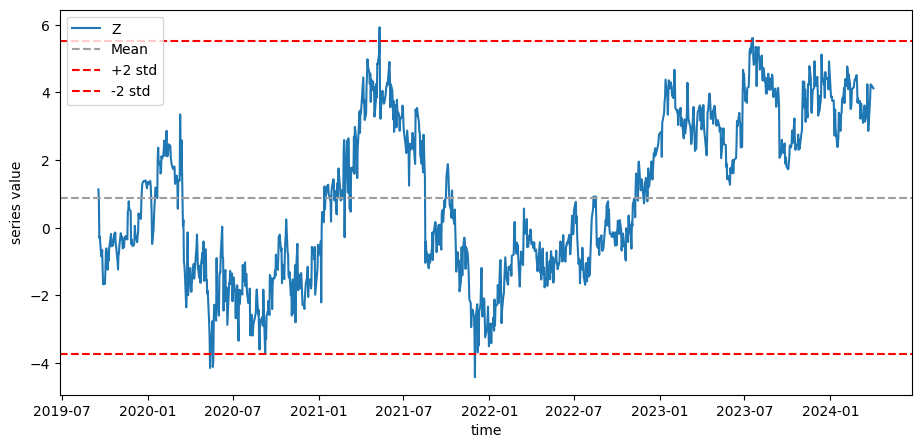

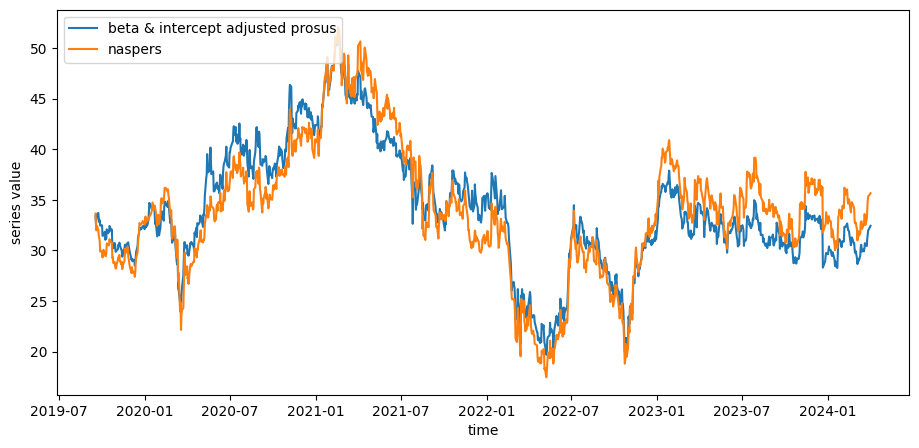

In [4]:
explore_cointegration(main_df["4. close_prosus"], main_df["4. close_naspers"], stock1_name="prosus", stock2_name="naspers")

c:\programming\bollore-data-project\notebooks\..\cointegration_and_stationarity.py:121: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  rolling_beta.loc[window_S1.index[-1], 'beta'] = results.params[1]
c:\programming\bollore-data-project\notebooks\..\cointegration_and_stationarity.py:121: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  rolling_beta.loc[window_S1.index[-1], 'beta'] = results.params[1]
c:\programming\bollore-data-project\notebooks\..\cointegration_and_stationarity.py:121: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as 

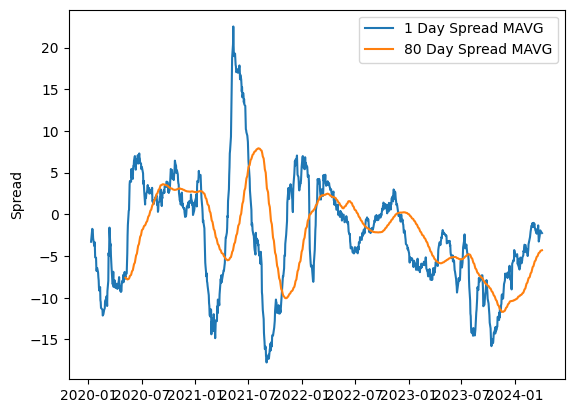

In [5]:
explore_cointegration_moving_averages(main_df["4. close_prosus"], main_df["4. close_naspers"], stock1_name="stock1", stock2_name="stock2")

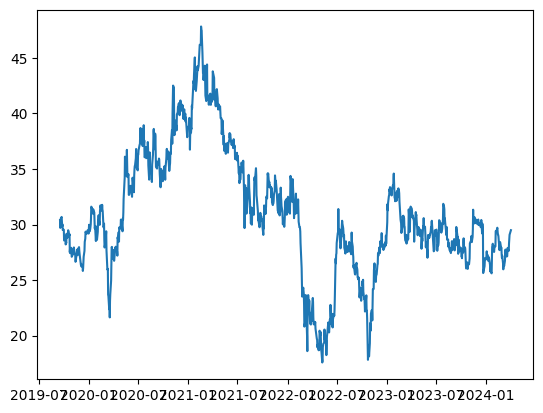

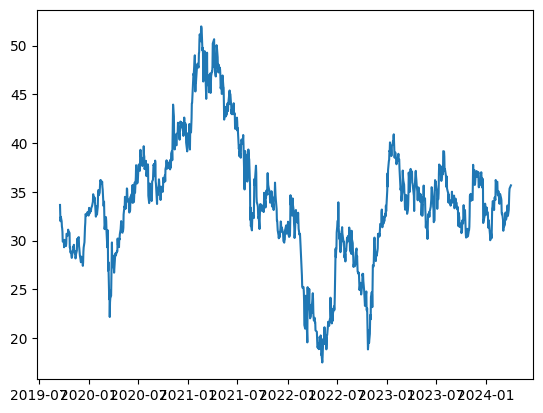

In [6]:
plt.plot(main_df["4. close_prosus"])
plt.show()
plt.plot(main_df["4. close_naspers"])
plt.show()